<a href="https://colab.research.google.com/github/sarwathasan72-svg/Masai_IIT_AIML/blob/main/evaluating_regression_performance_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (7, 4.5)
np.random.seed(42)


In [3]:
# The exact worked example from the slide deck
demo = pd.DataFrame({
    "size_sqft": [600, 800, 1000, 1200, 1500],
    "actual_price_L": [40, 55, 58, 65, 90],
    "predicted_price_L": [40, 50, 60, 70, 85],
})
demo

,size_sqft,actual_price_L,predicted_price_L
0,600,40,40
1,800,55,50
2,1000,58,60
3,1200,65,70
4,1500,90,85


In [4]:

demo["residual"] = demo["actual_price_L"] - demo["predicted_price_L"]
demo["squared_residual"] = demo["residual"] ** 2
demo

,size_sqft,actual_price_L,predicted_price_L,residual,squared_residual
0,600,40,40,0,0
1,800,55,50,5,25
2,1000,58,60,-2,4
3,1200,65,70,-5,25
4,1500,90,85,5,25


In [5]:
n = len(demo)
sum_squared_residuals = demo["squared_residual"].sum()
mse_manual = sum_squared_residuals / n

print(f"Sum of squared residuals: {sum_squared_residuals}")
print(f"n: {n}")
print(f"MSE (manual) = {sum_squared_residuals} / {n} = {mse_manual}")


Sum of squared residuals: 79
n: 5
MSE (manual) = 79 / 5 = 15.8


In [6]:
# Now verify with scikit-learn's built-in function — this is what you'll use in practice.
mse_sklearn = mean_squared_error(demo["actual_price_L"], demo["predicted_price_L"])
print(f"MSE (sklearn) = {mse_sklearn}")
assert np.isclose(mse_manual, mse_sklearn), "Manual and sklearn MSE should match!"
print("Manual calculation matches sklearn ✔")

MSE (sklearn) = 15.8
Manual calculation matches sklearn ✔


In [7]:
# RMSE — putting MSE back into real units

# MSE is in ₹Lakhs², which is awkward to reason about. Taking the square root brings it back to ₹Lakhs.

rmse_manual = np.sqrt(mse_manual)
print(f"RMSE = √{mse_manual} = {rmse_manual:.2f} ₹ Lakhs")
print("Interpretation: our predictions are typically off by roughly this much, in real terms.")



RMSE = √15.8 = 3.97 ₹ Lakhs
Interpretation: our predictions are typically off by roughly this much, in real terms.


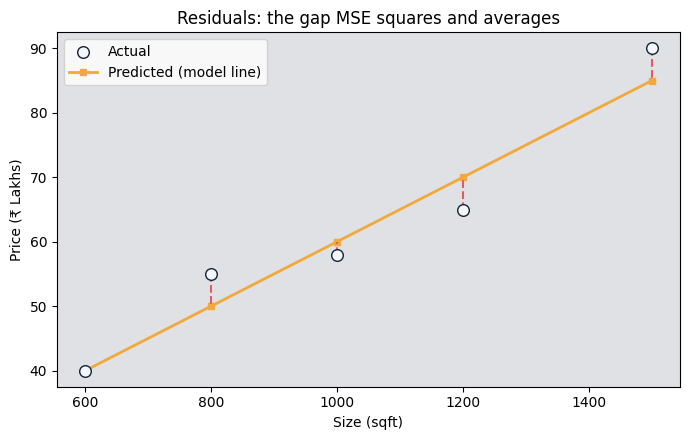

In [9]:
# Visualizing residuals

# The dashed lines below are exactly what gets squared and averaged in MSE.

fig, ax = plt.subplots()
ax.scatter(
    demo["size_sqft"],
    demo["actual_price_L"],
    color="#F3F7FB",
    edgecolor="#122238",
    s=70, zorder=3,
    label="Actual"
    )

ax.plot(
    demo["size_sqft"],
    demo["predicted_price_L"],
    color="#F2A93B",
    linewidth=2,
    marker="s",
    markersize=5,
    label="Predicted (model line)"
    )

for _, row in demo.iterrows():
    ax.plot([row["size_sqft"], row["size_sqft"]],
            [row["actual_price_L"], row["predicted_price_L"]],
            color="#E15B64", linestyle="--", linewidth=1.5, zorder=2)

ax.set_facecolor("#12223822")
ax.set_xlabel("Size (sqft)")
ax.set_ylabel("Price (₹ Lakhs)")
ax.set_title("Residuals: the gap MSE squares and averages")
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
# 3. R-squared — from scratch

# R² compares your model's error to the error of the simplest possible baseline: always predict the mean.


y_actual = demo["actual_price_L"].values
y_pred = demo["predicted_price_L"].values

y_mean = y_actual.mean()
ss_res = np.sum((y_actual - y_pred) ** 2)
ss_tot = np.sum((y_actual - y_mean) ** 2)

r2_manual = 1 - (ss_res / ss_tot)

print(f"Mean actual price (ȳ): {y_mean}")
print(f"SS_res (model's error):    {ss_res}")
print(f"SS_tot (baseline's error): {ss_tot:.2f}")
print(f"R² = 1 - {ss_res}/{ss_tot:.2f} = {r2_manual:.4f}")


Mean actual price (ȳ): 61.6
SS_res (model's error):    79
SS_tot (baseline's error): 1341.20
R² = 1 - 79/1341.20 = 0.9411


In [11]:
r2_sklearn = r2_score(y_actual, y_pred)
print(f"R² (sklearn) = {r2_sklearn:.4f}")
assert np.isclose(r2_manual, r2_sklearn), "Manual and sklearn R² should match!"
print("Manual calculation matches sklearn ✔")

# Interpretation: an R² of ~0.94 means the model explains about 94% of the variation in apartment prices — a strong fit. The remaining ~6% is unexplained (noise, or factors the model doesn't capture, like floor number or locality).


R² (sklearn) = 0.9411
Manual calculation matches sklearn ✔
